In [39]:
import time
import os
import numpy as np
import pandas as pd
import joblib
import pygad
import pyswarms.single as pso
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

In [40]:
datasets = {}

sizes = {'small': 50, 'large': 1500}

for name, size in sizes.items():
    n_feat = 5 if name == 'small' else 12
    df = pd.read_csv(f"datasets/ds_size{size}_feat{n_feat}.csv")
    datasets[name] = (df.drop('collision', axis=1), df['collision'])

train_test_data = {}
for name, (X, y) in datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    train_test_data[name] = (X_tr, X_te, y_tr, y_te)

param_ranges = {
    'dtree': {'max_depth': (1, 20), 'min_samples_split': (2, 20)},
    'knn': {'n_neighbors': [3, 5, 7]} 
}


os.makedirs("optimized_models", exist_ok=True)
results_log = {}

best_models=["knn", "dtree"]

In [41]:
for model_name in best_models:
    results_log.setdefault(model_name, {})
    print(f"\n[PyGAD] Модель: {model_name.upper()}")
    
    for ds_name in sizes.keys():
        print(f"   Датасет: {ds_name}")
        X_tr, X_te, y_tr, y_te = train_test_data[ds_name]
        
        if model_name == 'dtree':
            num_genes = 2
            gene_space = [{'low': param_ranges['dtree']['max_depth'][0], 'high': param_ranges['dtree']['max_depth'][1]},
                          {'low': param_ranges['dtree']['min_samples_split'][0], 'high': param_ranges['dtree']['min_samples_split'][1]}]
            gene_type = [int, int]
            def params_from_genome(genome): return {'max_depth': int(genome[0]), 'min_samples_split': int(genome[1])}
        else:
            num_genes = 2
            gene_space = [{'low': param_ranges['knn']['n_neighbors'][0], 'high': param_ranges['knn']['n_neighbors'][1]},
                          {'low': 0.0, 'high': 1.0}]
            gene_type = [int, float]
            def params_from_genome(genome): return {'n_neighbors': int(genome[0]), 'weights': 'distance' if genome[1] > 0.5 else 'uniform'}

        def fitness_func(ga_instance, genome, solution_idx):
            params = params_from_genome(genome)
            try:
                model = DecisionTreeClassifier(**params, random_state=42) if model_name == 'dtree' else KNeighborsClassifier(**params)
                model.fit(X_tr, y_tr)
                return accuracy_score(y_te, model.predict(X_te))
            except:
                return 0.01

        ga_config = {
            'num_generations': 20, 'num_parents_mating': 4, 'sol_per_pop': 10,
            'num_genes': num_genes, 'gene_space': gene_space, 'gene_type': gene_type,
            'fitness_func': fitness_func, 'parent_selection_type': 'sss',
            'crossover_type': 'single_point', 'mutation_type': 'random',
            'mutation_probability': 0.25, 'keep_parents': 1, 'random_seed': 42
        }

        start = time.time()
        ga_instance = pygad.GA(**ga_config)
        ga_instance.run()
        time_ga = time.time() - start
        
        best_solution, best_fitness, _ = ga_instance.best_solution()
        params_ga = params_from_genome(best_solution)
        print(f"    PyGAD Fitness: {best_fitness:.4f} | {time_ga:.2f}s")

        model_ga = DecisionTreeClassifier(**params_ga, random_state=42) if model_name == 'dtree' else KNeighborsClassifier(**params_ga)
        model_ga.fit(X_tr, y_tr)
        y_pred_ga = model_ga.predict(X_te)
        
        acc_ga = accuracy_score(y_te, y_pred_ga)
        f1_ga = f1_score(y_te, y_pred_ga, average='weighted')
        precision_ga = precision_score(y_te, y_pred_ga, average='weighted')
        recall_ga = recall_score(y_te, y_pred_ga, average='weighted')
        
        joblib.dump(model_ga, f"optimized_models/{model_name}_{ds_name}_pygad.pkl")
        
        results_log[model_name].setdefault(ds_name, {})
        results_log[model_name][ds_name]['pygad'] = {
            'params': params_ga, 'time': time_ga, 
            'acc': acc_ga, 'f1': f1_ga, 'precision': precision_ga, 'recall': recall_ga
        }


[PyGAD] Модель: KNN
   Датасет: small
    PyGAD Fitness: 0.9000 | 0.31s
   Датасет: large
    PyGAD Fitness: 0.7533 | 0.71s

[PyGAD] Модель: DTREE
   Датасет: small
    PyGAD Fitness: 0.9000 | 0.32s
   Датасет: large
    PyGAD Fitness: 0.7333 | 0.44s


In [42]:
for model_name in best_models:
    results_log.setdefault(model_name, {})
    print(f"\n[PySwarms] Модель: {model_name.upper()}")
    
    for ds_name in sizes.keys():
        print(f"   Датасет: {ds_name}")
        X_tr, X_te, y_tr, y_te = train_test_data[ds_name]
        
        if model_name == 'dtree':
            dimensions = 2
            bounds = (np.array([param_ranges['dtree']['max_depth'][0], param_ranges['dtree']['min_samples_split'][0]]),
                      np.array([param_ranges['dtree']['max_depth'][1], param_ranges['dtree']['min_samples_split'][1]]))
            def particle_to_hyperparams(p):
                return {'max_depth': int(np.round(p[0])), 'min_samples_split': int(np.round(p[1]))}
        else:  # knn
            dimensions = 2
            bounds = (np.array([param_ranges['knn']['n_neighbors'][0], 0.0]),
                      np.array([param_ranges['knn']['n_neighbors'][1], 1.0]))
            def particle_to_hyperparams(p):
                return {'n_neighbors': int(np.round(p[0])), 'weights': 'distance' if p[1] > 0.5 else 'uniform'}

        def objective_function(particles):
            scores = []
            for p in particles:
                try:
                    params = particle_to_hyperparams(p)
                    model = DecisionTreeClassifier(**params, random_state=42) if model_name == 'dtree' else KNeighborsClassifier(**params)
                    model.fit(X_tr, y_tr)
                    scores.append(1.0 - accuracy_score(y_te, model.predict(X_te)))
                except:
                    scores.append(2.0)
            return np.array(scores)

        options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
        start = time.time()
        optimizer = pso.GlobalBestPSO(n_particles=10, dimensions=dimensions, options=options, bounds=bounds)
        best_cost, best_pos = optimizer.optimize(objective_function, iters=20, verbose=False)
        time_pso = time.time() - start
        
        params_pso = particle_to_hyperparams(best_pos)
        print(f"   PySwarms Cost: {best_cost:.4f} (Acc: {1-best_cost:.4f}) | {time_pso:.2f}s")

        model_pso = DecisionTreeClassifier(**params_pso, random_state=42) if model_name == 'dtree' else KNeighborsClassifier(**params_pso)
        model_pso.fit(X_tr, y_tr)
        y_pred_pso = model_pso.predict(X_te)
        
        acc_pso = accuracy_score(y_te, y_pred_pso)
        f1_pso = f1_score(y_te, y_pred_pso, average='weighted')
        precision_pso = precision_score(y_te, y_pred_pso, average='weighted')
        recall_pso = recall_score(y_te, y_pred_pso, average='weighted')
        
        joblib.dump(model_pso, f"optimized_models/{model_name}_{ds_name}_pyswarms.pkl")
        
        results_log[model_name].setdefault(ds_name, {})
        results_log[model_name][ds_name]['pyswarms'] = {
            'params': params_pso, 'time': time_pso,
            'acc': acc_pso, 'f1': f1_pso, 'precision': precision_pso, 'recall': recall_pso
        }


[PySwarms] Модель: KNN
   Датасет: small
   PySwarms Cost: 0.1000 (Acc: 0.9000) | 0.69s
   Датасет: large
   PySwarms Cost: 0.2467 (Acc: 0.7533) | 2.33s

[PySwarms] Модель: DTREE
   Датасет: small
   PySwarms Cost: 0.1000 (Acc: 0.9000) | 0.59s
   Датасет: large
   PySwarms Cost: 0.2667 (Acc: 0.7333) | 1.21s


In [43]:
dir_original = "models"

for model_name in best_models:
    results_log.setdefault(model_name, {})
    print(f"\n[GridSearchCV] Модель: {model_name.upper()}")
    
    for ds_name in sizes.keys():
        print(f"   Датасет: {ds_name}")
        X_tr, X_te, y_tr, y_te = train_test_data[ds_name]
        
        path_orig = f"{dir_original}/{model_name}_{ds_name}.pkl"
            
        model_gs = joblib.load(path_orig)
        y_pred_gs = model_gs.predict(X_te)
        
        # Расчёт всех метрик
        acc_gs = accuracy_score(y_te, y_pred_gs)
        f1_gs = f1_score(y_te, y_pred_gs, average='weighted')
        precision_gs = precision_score(y_te, y_pred_gs, average='weighted')
        recall_gs = recall_score(y_te, y_pred_gs, average='weighted')
        
        if hasattr(model_gs, 'named_steps'):
            classifier = model_gs.named_steps['classifier']
            if model_name == 'dtree':
                params_gs = {
                    'max_depth': classifier.max_depth,
                    'min_samples_split': classifier.min_samples_split
                }
            else:
                params_gs = {
                    'n_neighbors': classifier.n_neighbors
                }
            
        results_log[model_name].setdefault(ds_name, {})
        results_log[model_name][ds_name]['gridsearch'] = {
            'params': params_gs, 'time': '-',
            'acc': acc_gs, 'f1': f1_gs, 
            'precision': precision_gs, 'recall': recall_gs
        }
        print(f"   Accuracy: {acc_gs:.4f} | Params: {params_gs}")


[GridSearchCV] Модель: KNN
   Датасет: small
   Accuracy: 0.9000 | Params: {'n_neighbors': 3}
   Датасет: large
   Accuracy: 0.8500 | Params: {'n_neighbors': 7}

[GridSearchCV] Модель: DTREE
   Датасет: small
   Accuracy: 0.9000 | Params: {'max_depth': 5, 'min_samples_split': 2}
   Датасет: large
   Accuracy: 0.9400 | Params: {'max_depth': 10, 'min_samples_split': 2}


In [44]:
rows = []

for model_name, datasets in results_log.items():
    for ds_size, methods in datasets.items():
        for method_name, metrics in methods.items():
            # Определение названия метода
            if method_name == 'pygad':
                method_display = 'PyGAD'
            elif method_name == 'pyswarms':
                method_display = 'PySwarms'
            elif method_name == 'gridsearch':
                method_display = 'GridSearchCV'
            else:
                method_display = method_name.upper()
            
            # Форматируем параметры в читаемую строку
            params = metrics.get('params', {})
            if isinstance(params, dict):
                # Создаём короткую строку с параметрами
                params_parts = []
                for key, value in params.items():
                    # Пропускаем стандартные параметры sklearn
                    if key not in ['random_state', 'n_jobs', 'weights']:
                        params_parts.append(f"{key}={value}")
                params_str = '{' + ', '.join(params_parts) + '}'
            else:
                params_str = str(params)
            
            row = {
                'Модель': model_name.upper(),
                'Датасет': ds_size,
                'Метод': method_display,
                'Время (с)': round(metrics['time'], 4) if isinstance(metrics['time'], (int, float)) else '-',
                'Accuracy': round(metrics['acc'], 4),
                'Precision': round(metrics['precision'], 4),
                'Recall': round(metrics['recall'], 4),
                'F1-score': round(metrics['f1'], 4),
                'Параметры': params_str
            }
            
            rows.append(row)

df_results = pd.DataFrame(rows)

# Сортировка и отображение
df_sorted = df_results.sort_values(['Модель', 'Датасет', 'Метод']).reset_index(drop=True)
display(df_sorted)


,Модель,Датасет,Метод,Время (с),Accuracy,Precision,Recall,F1-score,Параметры
0,DTREE,large,GridSearchCV,-,0.9400,0.9396,0.9400,0.9393,"{max_depth=10, min_samples_split=2}"
1,DTREE,large,PyGAD,0.4387,0.7333,0.7228,0.7333,0.7268,"{max_depth=6, min_samples_split=9}"
2,DTREE,large,PySwarms,1.2108,0.7333,0.7228,0.7333,0.7268,"{max_depth=6, min_samples_split=9}"
3,DTREE,small,GridSearchCV,-,0.9000,0.8100,0.9000,0.8526,"{max_depth=5, min_samples_split=2}"
4,DTREE,small,PyGAD,0.3229,0.9000,0.8100,0.9000,0.8526,"{max_depth=15, min_samples_split=2}"
5,DTREE,small,PySwarms,0.594,0.9000,0.8100,0.9000,0.8526,"{max_depth=13, min_samples_split=18}"
6,KNN,large,GridSearchCV,-,0.8500,0.8598,0.8500,0.8351,{n_neighbors=7}
7,KNN,large,PyGAD,0.7143,0.7533,0.7335,0.7533,0.7315,{n_neighbors=3}
8,KNN,large,PySwarms,2.3269,0.7533,0.7335,0.7533,0.7315,{n_neighbors=3}
9,KNN,small,GridSearchCV,-,0.9000,0.8100,0.9000,0.8526,{n_neighbors=3}


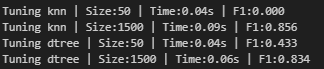

Grid search показывает лучший результат за лучшее время
PyGad отработал быстрее, чем PySwarms, при этом метрики у них одиннаковые. Помимо этого на small DTREE max_depth = 15 (13), что в сравнении с gridsearch является большим значеним (может быть следствием переобучения)
PyGad и PySwarms в половине случаем пришли к одиннаковым гиперпараметрам (в large), но отличаются в другой половине (small)
Возможно данные не совсем подходящие для этих двух алгоритмов, либо их недостаточно, чтобы потенциал методов
